In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_dir = '/content/drive/MyDrive/ML1/data/kaggle_data'

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [ ]:
import pandas as pd

In [ ]:
raw_df = pd.read_csv(f'{data_dir}/train.csv')

In [ ]:
import os
print('ML1:     ', [f for f in os.listdir('/content/drive/MyDrive/ML1') if f.endswith('.py')])
print('ML1/data:', [f for f in os.listdir('/content/drive/MyDrive/ML1/data') if f.endswith('.py')])

ML1:      ['process_bank_churn.py']
ML1/data: []


In [ ]:
import sys, importlib
sys.path.append('/content/drive/MyDrive/ML1')
importlib.invalidate_caches()

from process_bank_churn import preprocess_data, preprocess_new_data
print('ok')

ok


In [ ]:
data = preprocess_data(raw_df, scaler_numeric=True)   # для kNN скейлер обов'язковий

In [ ]:
print('scaler:', data['scaler'])
print(data['X_train'].shape, data['X_val'].shape)

X_train, train_targets = data['X_train'], data['train_targets']
X_val, val_targets = data['X_val'], data['val_targets']

data['X_train'][data['numeric_cols']].describe().T[['mean', 'std', 'min', 'max']]

scaler: StandardScaler()
(12000, 13) (3000, 13)


,mean,std,min,max
CreditScore,4.319508e-16,1.000042,-3.149928,2.642814
Age,4.736952e-17,1.000042,-2.419227,4.461985
Tenure,3.375078e-17,1.000042,-1.806736,1.787983
Balance,7.579123e-17,1.000042,-0.717950,2.783767
NumOfProducts,3.937591e-17,1.000042,-1.108193,4.524299
HasCrCard,5.921189e-18,1.000042,-1.941514,0.515062
IsActiveMember,3.315866e-17,1.000042,-0.983306,1.016977
EstimatedSalary,-1.397401e-16,1.000042,-2.588003,1.798737


1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, train_targets)

print(knn.get_params())

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}


In [ ]:
from sklearn.metrics import roc_auc_score

train_auc = roc_auc_score(train_targets, knn.predict_proba(X_train)[:, 1])
val_auc   = roc_auc_score(val_targets,   knn.predict_proba(X_val)[:, 1])

print(f'Train AUROC: {train_auc:.4f}')
print(f'Val AUROC:   {val_auc:.4f}')

Train AUROC: 0.9610
Val AUROC:   0.8750


In [ ]:
for k in [1, 5, 50]:
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train, train_targets)
    tr = roc_auc_score(train_targets, m.predict_proba(X_train)[:, 1])
    vl = roc_auc_score(val_targets,   m.predict_proba(X_val)[:, 1])
    print(f'k={k:3d}  train {tr:.4f} | val {vl:.4f}')

k=  1  train 1.0000 | val 0.7637
k=  5  train 0.9610 | val 0.8750
k= 50  train 0.9274 | val 0.9162


**Висновок:**
Ця модель трохи краща за дефолтне дерево в попередній домашці (трейн 1 - перенавчання, 0,77 - валідація, розрив значний). Тут же отримали розрив помірний 0,086 тобто маємо high variance outcome. Ця модель краща за дефолтне дерево але гірша за налаштоване тому вона не є хорошою.

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [ ]:
from sklearn.model_selection import GridSearchCV

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
params_knn = {'n_neighbors': np.arange(1, 25)}   # сітку доведеться розширити див спробу з k=50

knn_gs = GridSearchCV(
    KNeighborsClassifier(),
    params_knn,
    cv=5,
    scoring='roc_auc', #за замовчуванням GridSearchCV оптимізує accuracy. На незбалансованих даних це дало б інший, гірший k. Метрика змагання — AUROC, тож оптимізуємо саме її.
    n_jobs=-1 #усі ядра. 24 значення × 5 фолдів = 120 навчань, а kNN повільний на predict. Без цього чекати довго.
)
knn_gs.fit(X_train, train_targets)

print(knn_gs.best_params_, round(knn_gs.best_score_, 4))
knn_best = knn_gs.best_estimator_

{'n_neighbors': np.int64(23)} 0.9117


In [ ]:
print(params_knn['n_neighbors'].min(), params_knn['n_neighbors'].max())
print(knn_gs.best_params_)

1 24
{'n_neighbors': np.int64(23)}


In [ ]:
cv_df = pd.DataFrame(knn_gs.cv_results_)[['param_n_neighbors', 'mean_test_score', 'std_test_score']]

In [ ]:
cv_df

,param_n_neighbors,mean_test_score,std_test_score
0,1,0.758156,0.013304
1,2,0.822049,0.013471
2,3,0.849214,0.011377
3,4,0.863856,0.012860
4,5,0.876234,0.013017
5,6,0.882401,0.013820
6,7,0.888079,0.014008
7,8,0.891995,0.013632
8,9,0.895593,0.012061
9,10,0.899054,0.011354


In [ ]:
params_knn = {'n_neighbors': np.arange(1, 151, 2)}

In [ ]:
print('вузька сітка:', knn_gs.best_params_, round(knn_gs.best_score_, 4))

вузька сітка: {'n_neighbors': np.int64(23)} 0.9117


In [ ]:
knn_gs = GridSearchCV(
    KNeighborsClassifier(),
    params_knn,
    cv=5,
    scoring='roc_auc', #за замовчуванням GridSearchCV оптимізує accuracy. На незбалансованих даних це дало б інший, гірший k. Метрика змагання — AUROC, тож оптимізуємо саме її.
    n_jobs=-1
)
knn_gs.fit(X_train, train_targets)


print(knn_gs.best_params_, round(knn_gs.best_score_, 4))
knn_best = knn_gs.best_estimator_

{'n_neighbors': np.int64(43)} 0.9146


In [ ]:
print(params_knn['n_neighbors'].min(), params_knn['n_neighbors'].max())
print(knn_gs.best_params_)

1 149
{'n_neighbors': np.int64(43)}


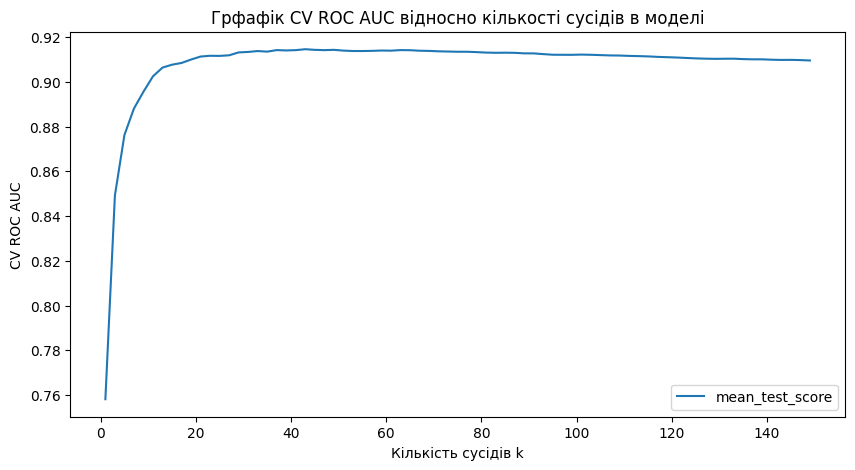

In [ ]:
cv_df = pd.DataFrame(knn_gs.cv_results_)[['param_n_neighbors', 'mean_test_score', 'std_test_score']]
cv_df.plot(x='param_n_neighbors', y='mean_test_score', figsize=(10, 5))
plt.xlabel('Кількість сусідів k')
plt.ylabel('CV ROC AUC')
plt.title('Грфафік CV ROC AUC відносно кількості сусідів в моделі')

plt.show()

In [ ]:
cv_df.loc[cv_df['mean_test_score'].idxmax()]

,21
param_n_neighbors,43.000000
mean_test_score,0.914581
std_test_score,0.006706


In [ ]:
knn_best = knn_gs.best_estimator_

train_auc = roc_auc_score(train_targets, knn_best.predict_proba(X_train)[:, 1])
val_auc   = roc_auc_score(val_targets,   knn_best.predict_proba(X_val)[:, 1])
print(f'Train AUROC: {train_auc:.4f}')
print(f'Val AUROC:   {val_auc:.4f}')

Train AUROC: 0.9290
Val AUROC:   0.9152


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pipe_gs = GridSearchCV(
    make_pipeline(StandardScaler(), KNeighborsClassifier()),
    {'kneighborsclassifier__n_neighbors': np.arange(1, 151, 2)},
    cv=5, scoring='roc_auc', n_jobs=-1
).fit(X_train, train_targets)

print(pipe_gs.best_params_, round(pipe_gs.best_score_, 4))
# окремий експеримент про вагу one-hot ознак у kNN: повне масштабування дамі-колонок погіршує модель, бо роздуває їхній внесок у відстань

{'kneighborsclassifier__n_neighbors': np.int64(39)} 0.9049


In [ ]:
#clean test витоку

from sklearn.compose import ColumnTransformer

data_raw = preprocess_data(raw_df, scaler_numeric=False)   # немасштабовані
X_train_raw = data_raw['X_train']

pre = ColumnTransformer(
    [('num', StandardScaler(), data_raw['numeric_cols'])],
    remainder='passthrough'
)

pipe_gs = GridSearchCV(
    make_pipeline(pre, KNeighborsClassifier()),
    {'kneighborsclassifier__n_neighbors': np.arange(1, 151, 2)},
    cv=5, scoring='roc_auc', n_jobs=-1
).fit(X_train_raw, data_raw['train_targets'])

print(pipe_gs.best_params_, round(pipe_gs.best_score_, 4))

{'kneighborsclassifier__n_neighbors': np.int64(43)} 0.9146


- зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?



GridSearchCV на 5 фолдах з scoring='roc_auc' знайшов оптимальне n_neighbors = 43 з CV ROC AUC 0.9146.
Спершу я взяла сітку 1–24, як у лекції, і отримала k=23 — тобто майже край сітки, що вже підозріло.
На розширеній сітці 1–149 максимум опинився всередині, крива має чіткий пік близько 43 і далі повільно спадає. Щоправда, плато там дуже пласке: різниця між k=23 і k=43 усього 0.003, тоді як розкид між фолдами 0.0067. Тож 43 — не якесь магічне число, а просто найвища точка на рівній ділянці 25–90. Я лишила саме його, бо при однаковій якості краще брати більший k: модель виходить простішою і стабільнішою.

Порівняно з дефолтним kNN з пункту 1 модель стала помітно кращою. Val AUROC зріс з 0.8750 до 0.9152, а розрив між train і val скоротився з 0.0860 до 0.0138.
Тобто помірне перенавчання, яке я діагностувала раніше, зникло — дефолтне k=5 було просто замалим для вибірки, модель орієнтувалась на п'ятьох найближчих і ловила локальний шум. І що приємно, CV-оцінка не збрехала: best_score_ 0.9146 і val 0.9152 практично збіглись, тобто крос-валідація дала чесний прогноз якості на нових даних.

А от дерево з попереднього ДЗ кращє, хоч і трохи: 0.9230 проти 0.9152. Думаю, справа в тому, що в цих даних багато категоріальних і бінарних ознак — Geography, Gender, HasCrCard, IsActiveMember. Дереву з ними легко, воно просто ставить поріг по колонці. А для kNN кожна така колонка стає повноцінним виміром у формулі відстані й радше додає шуму, ніж допомагає. Побічно це підтвердив мій експеримент із пайплайном:
коли я застосувала StandardScaler до всіх колонок разом, включно з one-hot, результат впав до 0.9049 — саме тому, що дамі-колонки отримали ще більшу вагу у відстані.

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [26]:
from sklearn.tree import DecisionTreeClassifier

params_dt_grid = {
    'max_depth': np.arange(1, 21, 2),
    'max_leaf_nodes': np.arange(2, 11)
}
print(params_dt_grid['max_depth'], params_dt_grid['max_leaf_nodes'])

[ 1  3  5  7  9 11 13 15 17 19] [ 2  3  4  5  6  7  8  9 10]


In [29]:
import time

dt_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params_dt_grid,
    cv=3, # кросвалідація на 3 фолди
    scoring='roc_auc',
    n_jobs=-1
)

start = time.time()
dt_gs.fit(X_train, train_targets)
grid_time = time.time() - start

print(f'GridSearchCV: {grid_time:.1f} c')
print(dt_gs.best_params_, round(dt_gs.best_score_, 4))

dt_best = dt_gs.best_estimator_

GridSearchCV: 12.6 c
{'max_depth': np.int64(5), 'max_leaf_nodes': np.int64(10)} 0.9014


In [36]:
dt_best = dt_gs.best_estimator_

train_auc = roc_auc_score(train_targets, dt_best.predict_proba(X_train)[:, 1])
val_auc   = roc_auc_score(val_targets,   dt_best.predict_proba(X_val)[:, 1])
print(f'Train AUROC: {train_auc:.4f}')
print(f'Val AUROC:   {val_auc:.4f}')

Train AUROC: 0.9015
Val AUROC:   0.9002


GridSearchCV не знаходить оптимум бо він знаходить найкраще в межах сітки, яку йому дали. Сітка обмежила max_leaf_nodes 10, а дереву на цих даних потрібно 32. Модель вийшла слабкою і гіршою за ручну.
Розрив train–val усього 0.0013 (найменший з усіх моделей, які я будувала) і це high bias: обидва числа низькі відносно того, що на цих даних досяжно (ручне дерево показувало 0.9271 на train, kNN — 0.9290). Дерево з десятьма листками просто не має ємності описати структуру даних, тому воно однаково посередньо працює і на тренуванні, і на валідації. Причина видна одразу: best_params_ вказав на max_leaf_nodes = 10, а це верхня межа сітки — пошук уперся в стінку, як і з початковою сіткою для kNN.

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [31]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [33]:
# оцінюю, наскільки велика сітка
print({k: len(v) for k, v in params_dt.items()})
print('усього комбінацій:', np.prod([len(v) for v in params_dt.values()]))

{'criterion': 2, 'splitter': 2, 'max_depth': 19, 'max_leaf_nodes': 18, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 3}
усього комбінацій: 65664


In [34]:
from sklearn.model_selection import RandomizedSearchCV

dt_rs = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    params_dt,
    n_iter=40,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

start = time.time()
dt_rs.fit(X_train, train_targets)
random_time = time.time() - start

print(f'RandomizedSearchCV: {random_time:.1f} c')
print(dt_rs.best_params_, round(dt_rs.best_score_, 4))

dt_random_search_best = dt_rs.best_estimator_

RandomizedSearchCV: 5.1 c
{'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'} 0.9109


In [37]:
dt_random_search_best = dt_rs.best_estimator_

train_auc = roc_auc_score(train_targets, dt_random_search_best.predict_proba(X_train)[:, 1])
val_auc   = roc_auc_score(val_targets,   dt_random_search_best.predict_proba(X_val)[:, 1])
print(f'Train AUROC: {train_auc:.4f}')
print(f'Val AUROC:   {val_auc:.4f}')

Train AUROC: 0.9169
Val AUROC:   0.9166


In [38]:
pd.DataFrame({
    'GridSearch (п.3)': pd.Series(dt_gs.best_params_),
    'RandomizedSearch (п.4)': pd.Series(dt_rs.best_params_)
})

,GridSearch (п.3),RandomizedSearch (п.4)
criterion,NaN,entropy
max_depth,5.0,16
max_features,NaN,None
max_leaf_nodes,10.0,14
min_samples_leaf,NaN,2
min_samples_split,NaN,20
splitter,NaN,best


RandomizedSearchCV відпрацював швидше за 5,1 с на відміну від п.3 з 12,6 с. Знайшов кращу моделp Train AUROC: 0.9169; Val AUROC:   0.9166. Aле ця модель не дотягнула до ручного перебору, бо також уперлась в границю 14 листків.


5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [39]:
test_raw_df = pd.read_csv(f'{data_dir}/test.csv')

X_test = preprocess_new_data(
    test_raw_df,
    input_cols=data['input_cols'],
    scaler=data['scaler'],
    encoder=data['encoder'],
    numeric_cols=data['numeric_cols'],
    categorical_cols=data['categorical_cols'],
)

assert list(X_test.columns) == data['input_cols'], 'порядок колонок не збігається!'
print(X_test.shape, '| очікується колонок:', X_train.shape[1])
print('пропусків:', X_test.isna().sum().sum())
X_test[data['numeric_cols']].describe().T[['mean', 'std']]

(10000, 13) | очікується колонок: 13
пропусків: 0


,mean,std
CreditScore,-0.010352,0.997743
Age,0.023922,1.003446
Tenure,0.005722,1.005688
Balance,-0.003002,1.000009
NumOfProducts,-0.008730,0.996845
HasCrCard,-0.024648,1.017180
IsActiveMember,-0.019369,0.999536
EstimatedSalary,0.011779,1.657963


In [40]:
pd.DataFrame({
    'train': raw_df['EstimatedSalary'].describe(),
    'test':  test_raw_df['EstimatedSalary'].describe()
})

,train,test
count,15000.000000,1.000000e+04
mean,117784.666193,1.185294e+05
std,45734.445888,7.558253e+04
min,11.580000,4.477300e+02
25%,83058.140000,8.341915e+04
50%,123584.870000,1.229254e+05
75%,156884.705000,1.557898e+05
max,199992.480000,6.090906e+06


In [41]:
mask = test_raw_df['EstimatedSalary'] > raw_df['EstimatedSalary'].max()
print('викидів:', mask.sum())
print(test_raw_df.loc[mask, 'EstimatedSalary'].sort_values(ascending=False).head(10))

викидів: 2
2182    6090905.51
4523    1247772.61
Name: EstimatedSalary, dtype: float64


In [43]:
# Фінальна модель
final_model = dt_random_search_best   # найкраща модель цього ДЗ, val AUROC 0.9166

test_raw_df = pd.read_csv(f'{data_dir}/test.csv') # Тестові дані

# Обрізаємо викиди в EstimatedSalary до діапазону тренувальних даних.
# У тесті знайдено 2 значення поза межами трейну (макс 6 090 906 при 199 992),
# які після масштабування давали б ~130 стандартних відхилень.
test_clipped = test_raw_df.copy()
test_clipped['EstimatedSalary'] = test_clipped['EstimatedSalary'].clip(
    lower=raw_df['EstimatedSalary'].min(),
    upper=raw_df['EstimatedSalary'].max()
)

# Препроцесинг навченими об'єктами (той самий scaler, що й для train)
X_test = preprocess_new_data(
    test_clipped,
    input_cols=data['input_cols'],
    scaler=data['scaler'],
    encoder=data['encoder'],
    numeric_cols=data['numeric_cols'],
    categorical_cols=data['categorical_cols'],
)

assert list(X_test.columns) == data['input_cols'], 'порядок колонок не збігається!'
print(X_test.shape, '| пропусків:', X_test.isna().sum().sum())
print(X_test[data['numeric_cols']].std().round(3).to_dict())

(10000, 13) | пропусків: 0
{'CreditScore': 0.998, 'Age': 1.003, 'Tenure': 1.006, 'Balance': 1.0, 'NumOfProducts': 0.997, 'HasCrCard': 1.017, 'IsActiveMember': 1.0, 'EstimatedSalary': 0.986}


In [44]:
# Передбачення і submission
test_raw_df['Exited'] = final_model.predict_proba(X_test)[:, 1]

submission = pd.read_csv(f'{data_dir}/sample_submission.csv')
submission['Exited'] = submission['id'].map(test_raw_df.set_index('id')['Exited'])

print('порожніх значень:', submission['Exited'].isna().sum())
print(submission['Exited'].describe())
display(submission.head())

submission.to_csv('submission_dt_random.csv', index=False)

порожніх значень: 0
count    10000.000000
mean         0.206747
std          0.284102
min          0.012115
25%          0.012115
50%          0.059486
75%          0.237911
max          1.000000
Name: Exited, dtype: float64


,id,Exited
0,15000,0.237911
1,15001,0.012115
2,15002,0.203947
3,15003,0.569848
4,15004,0.082171


In [45]:
print('унікальних значень ймовірності:', submission['Exited'].nunique())

унікальних значень ймовірності: 14


In [46]:
from google.colab import files
files.download('submission_dt_random.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Для сабміту взяла dt_random_search_best — найкращу модель цього ДЗ за val AUROC (0.9166). При підготовці тестових даних знайшла два рядки з аномальним EstimatedSalary (максимум 6 090 906 при 199 992 у трейні). Обрізала до діапазону тренувальних даних, після чого std усіх колонок ліг у межі 0.99–1.02.

Public score вийшов 0.91632 - практично збігся з валідаційним 0.9166, тобто локальна оцінка чесно передбачила поведінку на нових даних. Але private score - 0.90851, а дерево з ДЗ 2.3 дало 0.91397 на public і 0.91825 на private. Тобто на публічному лідерборді сьогоднішня модель виграла, а на приватному програла.